In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('stud.csv')


In [3]:
df.isnull().sum()


gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [4]:
df.isna().sum()


gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [8]:
df[df.duplicated()]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score


##
Their are no missing values and no duplicates



In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [10]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [11]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [15]:
numeric_feature = [feature for feature in df.columns if df[feature].dtype !='str']
categorical_feature = [feature for feature in df.columns if df[feature].dtype =='str']

print(len(numeric_feature),numeric_feature)
print(len(categorical_feature),categorical_feature)

3 ['math_score', 'reading_score', 'writing_score']
5 ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


## Creating column for total score and average score


In [19]:
df['Total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average'] = df['Total_score']/3
df.head(4)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333


In [25]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [23]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


## DATA VISUALIZATION

<Axes: xlabel='reading_score', ylabel='Count'>

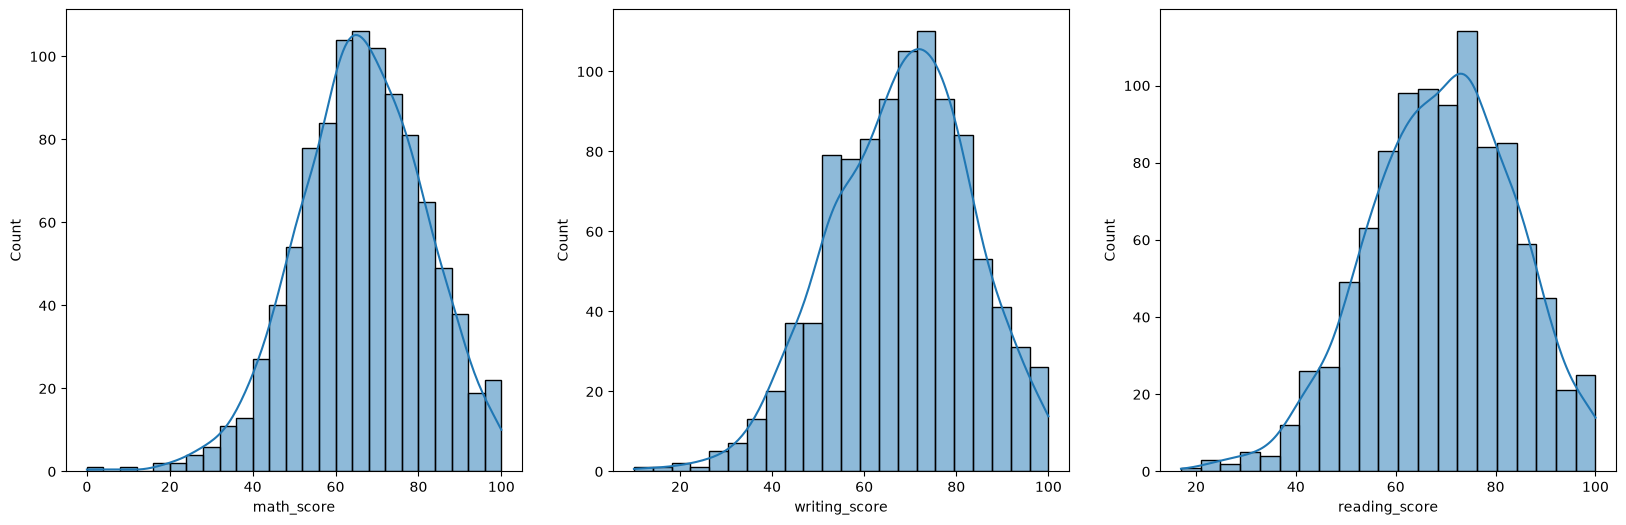

In [59]:
fig,ax = plt.subplots(1,3,figsize=(20,6))
sns.histplot(data=df['math_score'],kde=True,ax=ax[0])
sns.histplot(data=df['writing_score'],kde=True,ax=ax[1])
sns.histplot(data=df['reading_score'],kde=True,ax=ax[2])

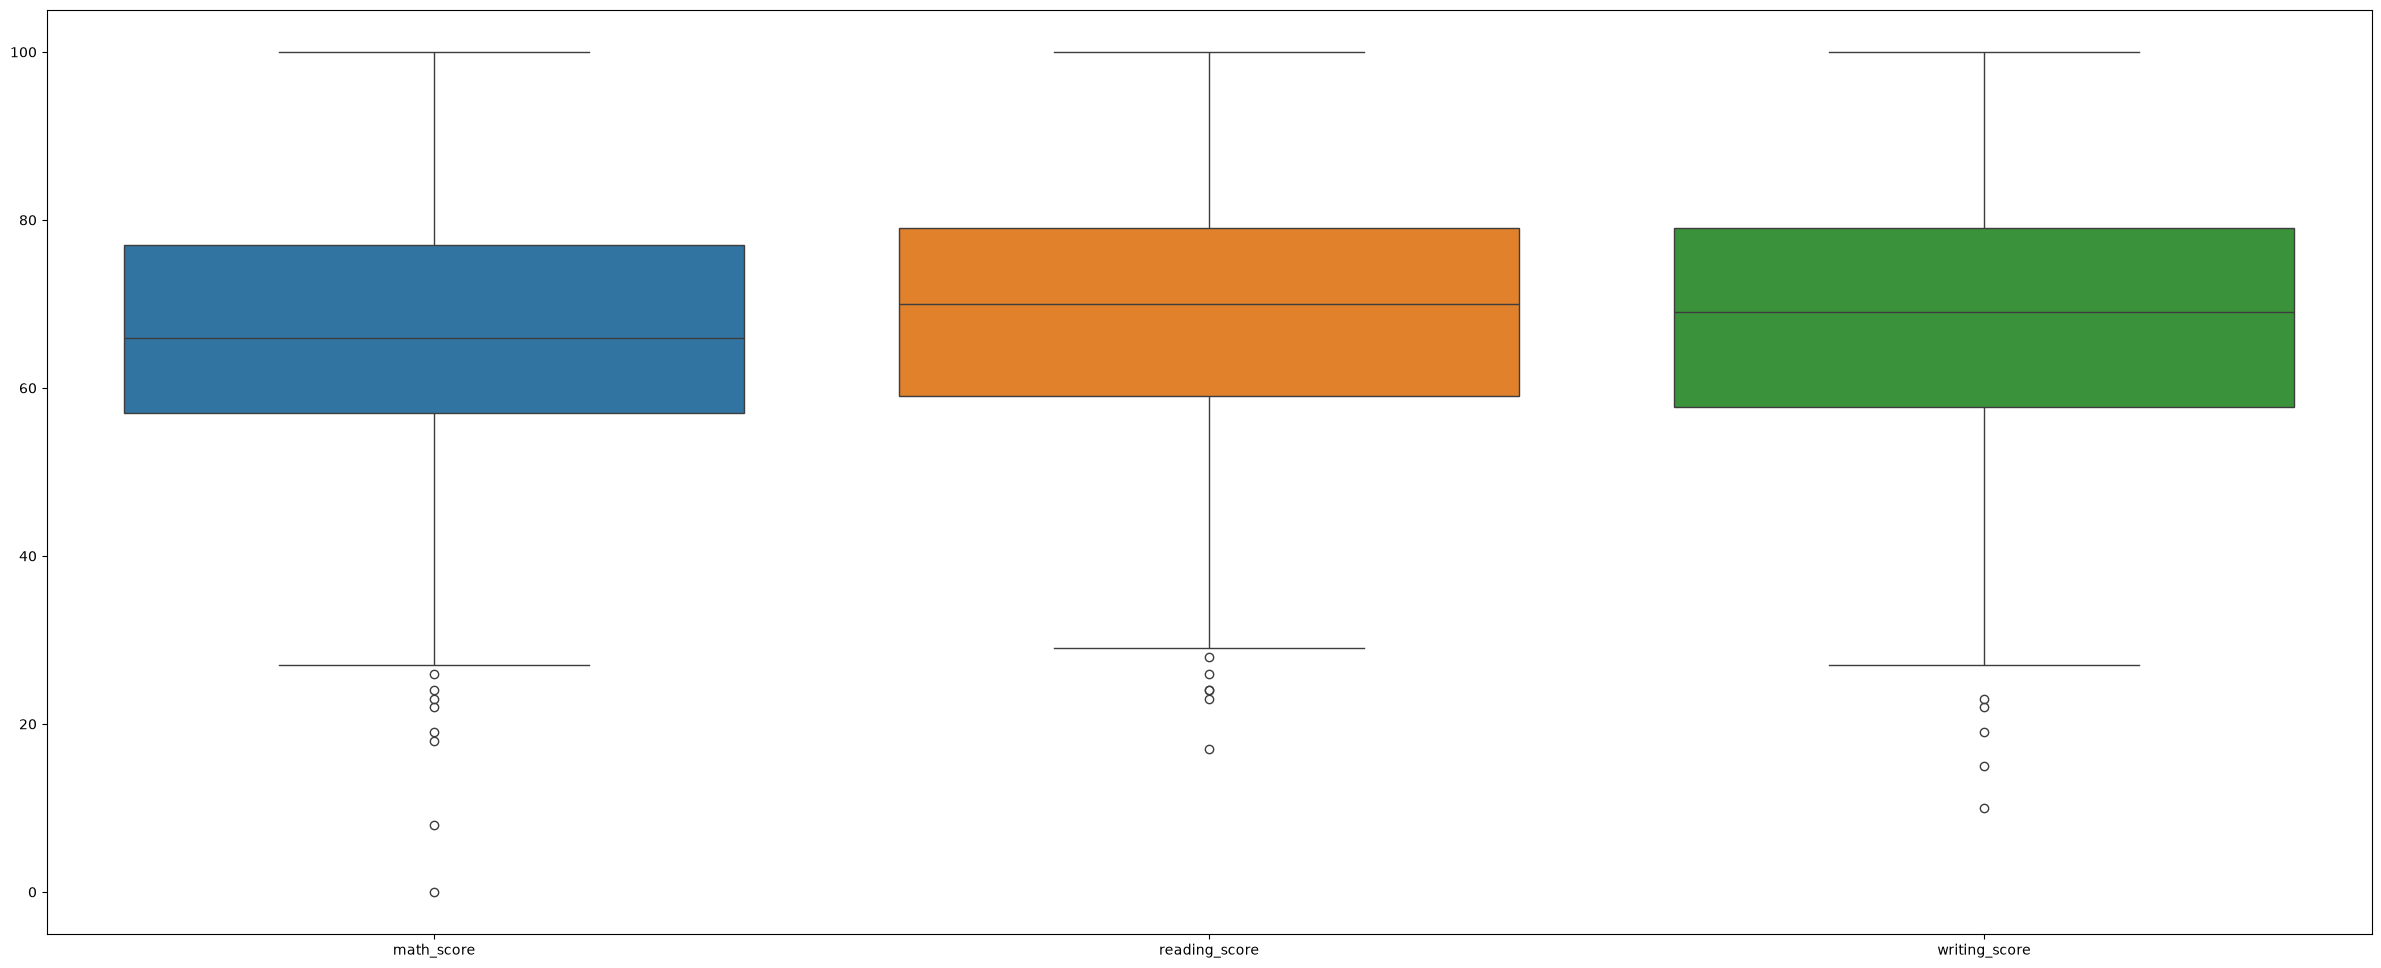

In [62]:
sns.boxplot(data=df[['math_score','reading_score','writing_score']])
plt.show()

<Axes: xlabel='gender', ylabel='reading_score'>

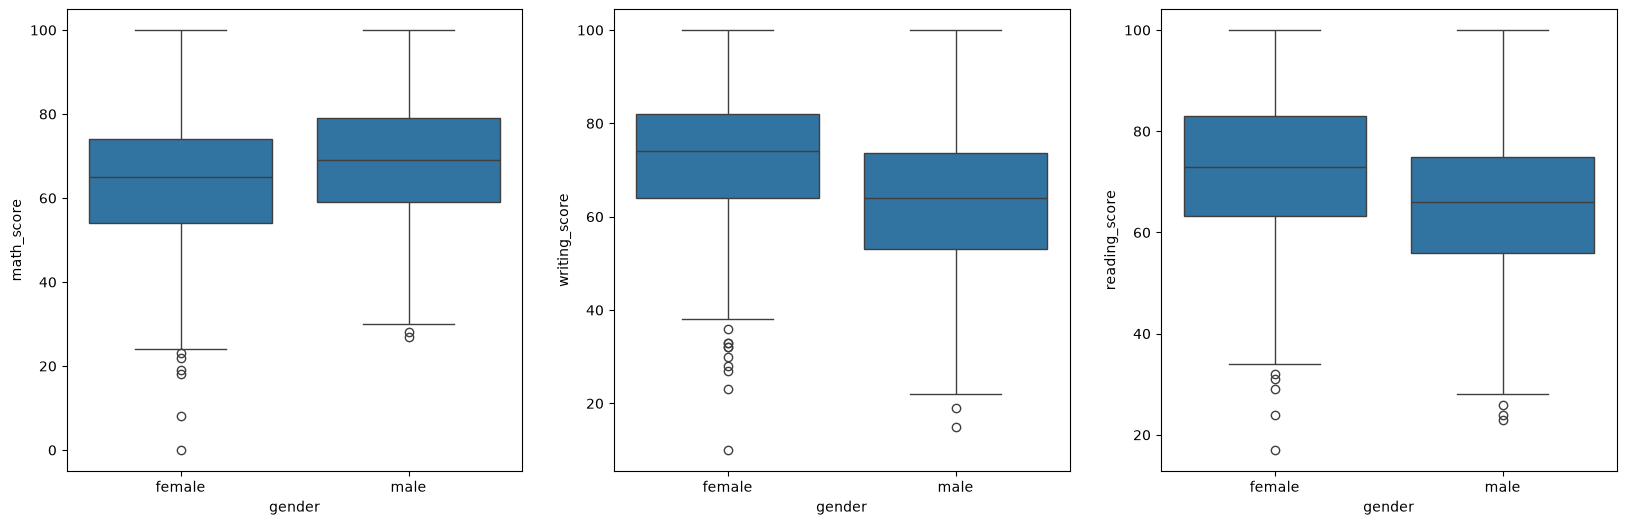

In [65]:
fig,ax = plt.subplots(1,3,figsize=(20,6))
sns.boxplot(x='gender',y="math_score",data=df,ax=ax[0])
sns.boxplot(x='gender',y="writing_score",data=df,ax=ax[1])
sns.boxplot(x='gender',y="reading_score",data=df,ax=ax[2])

<Axes: xlabel='test_preparation_course', ylabel='math_score'>

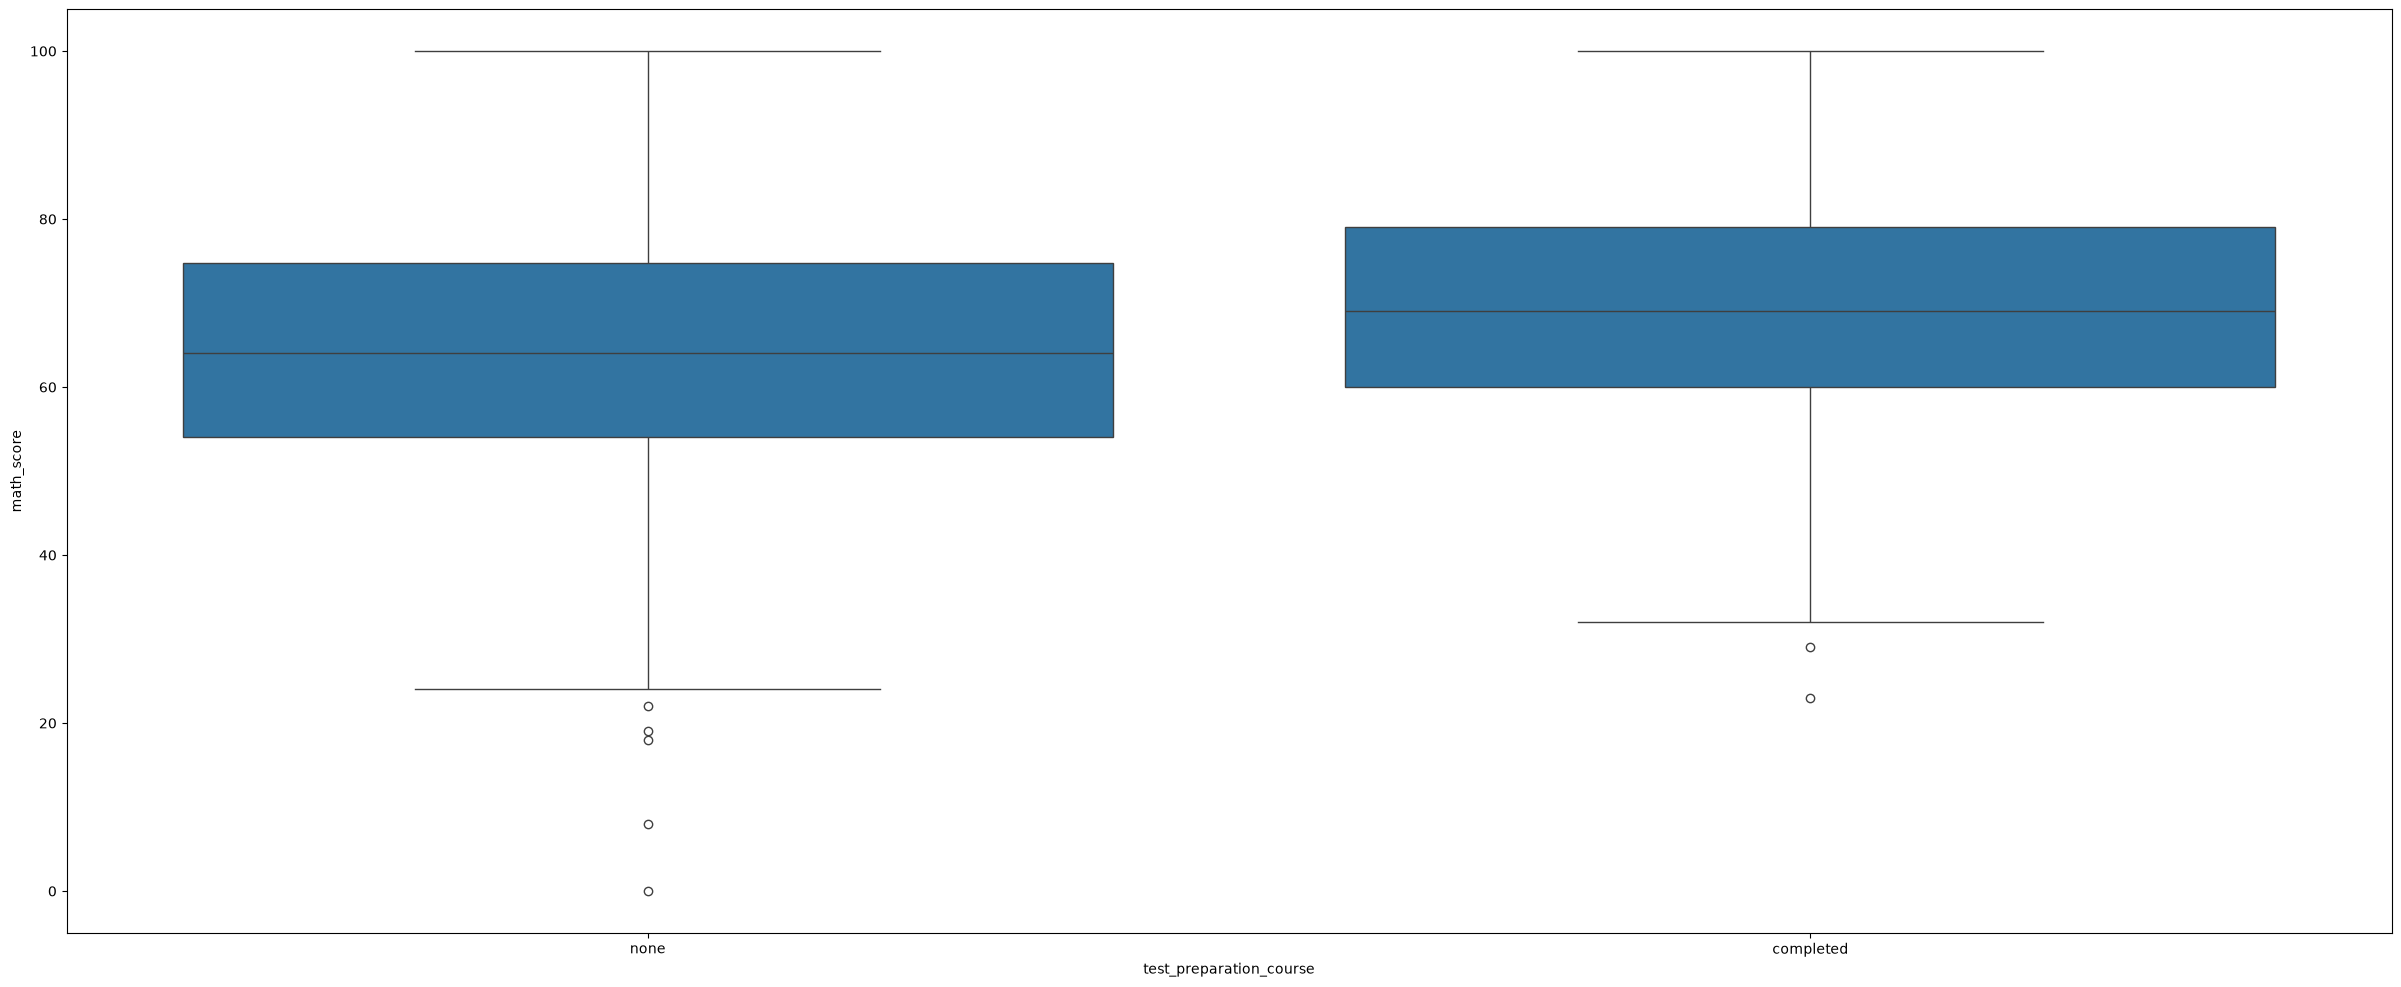

In [ ]:
sns.boxplot(
    x='test_preparation_course',
    y='math_score',
    data=df
)


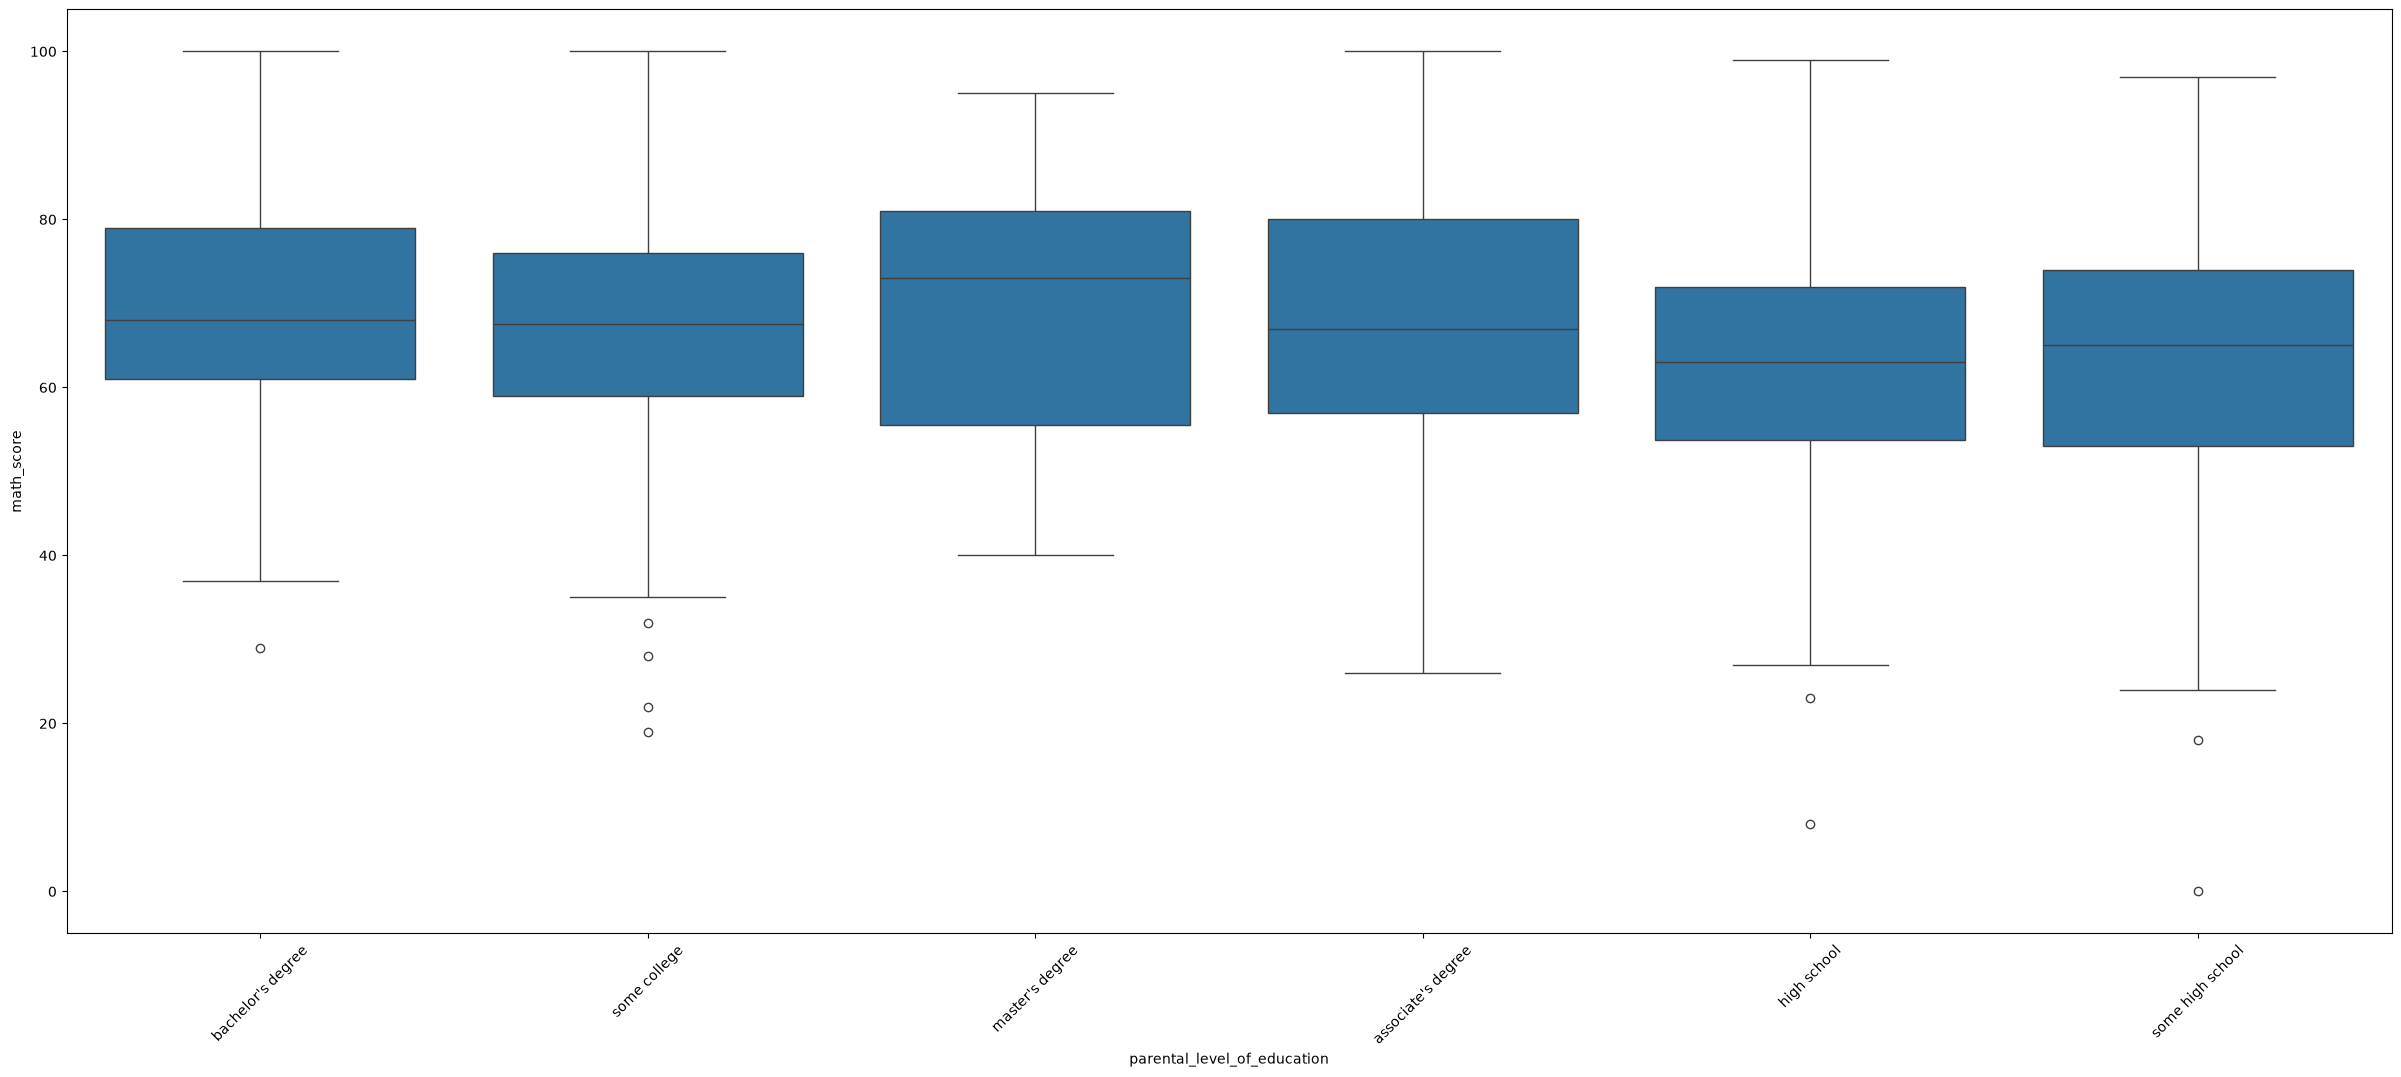

In [67]:
sns.boxplot(
    x='parental_level_of_education',
    y='math_score',
    data=df
)
plt.xticks(rotation=45)
plt.show()

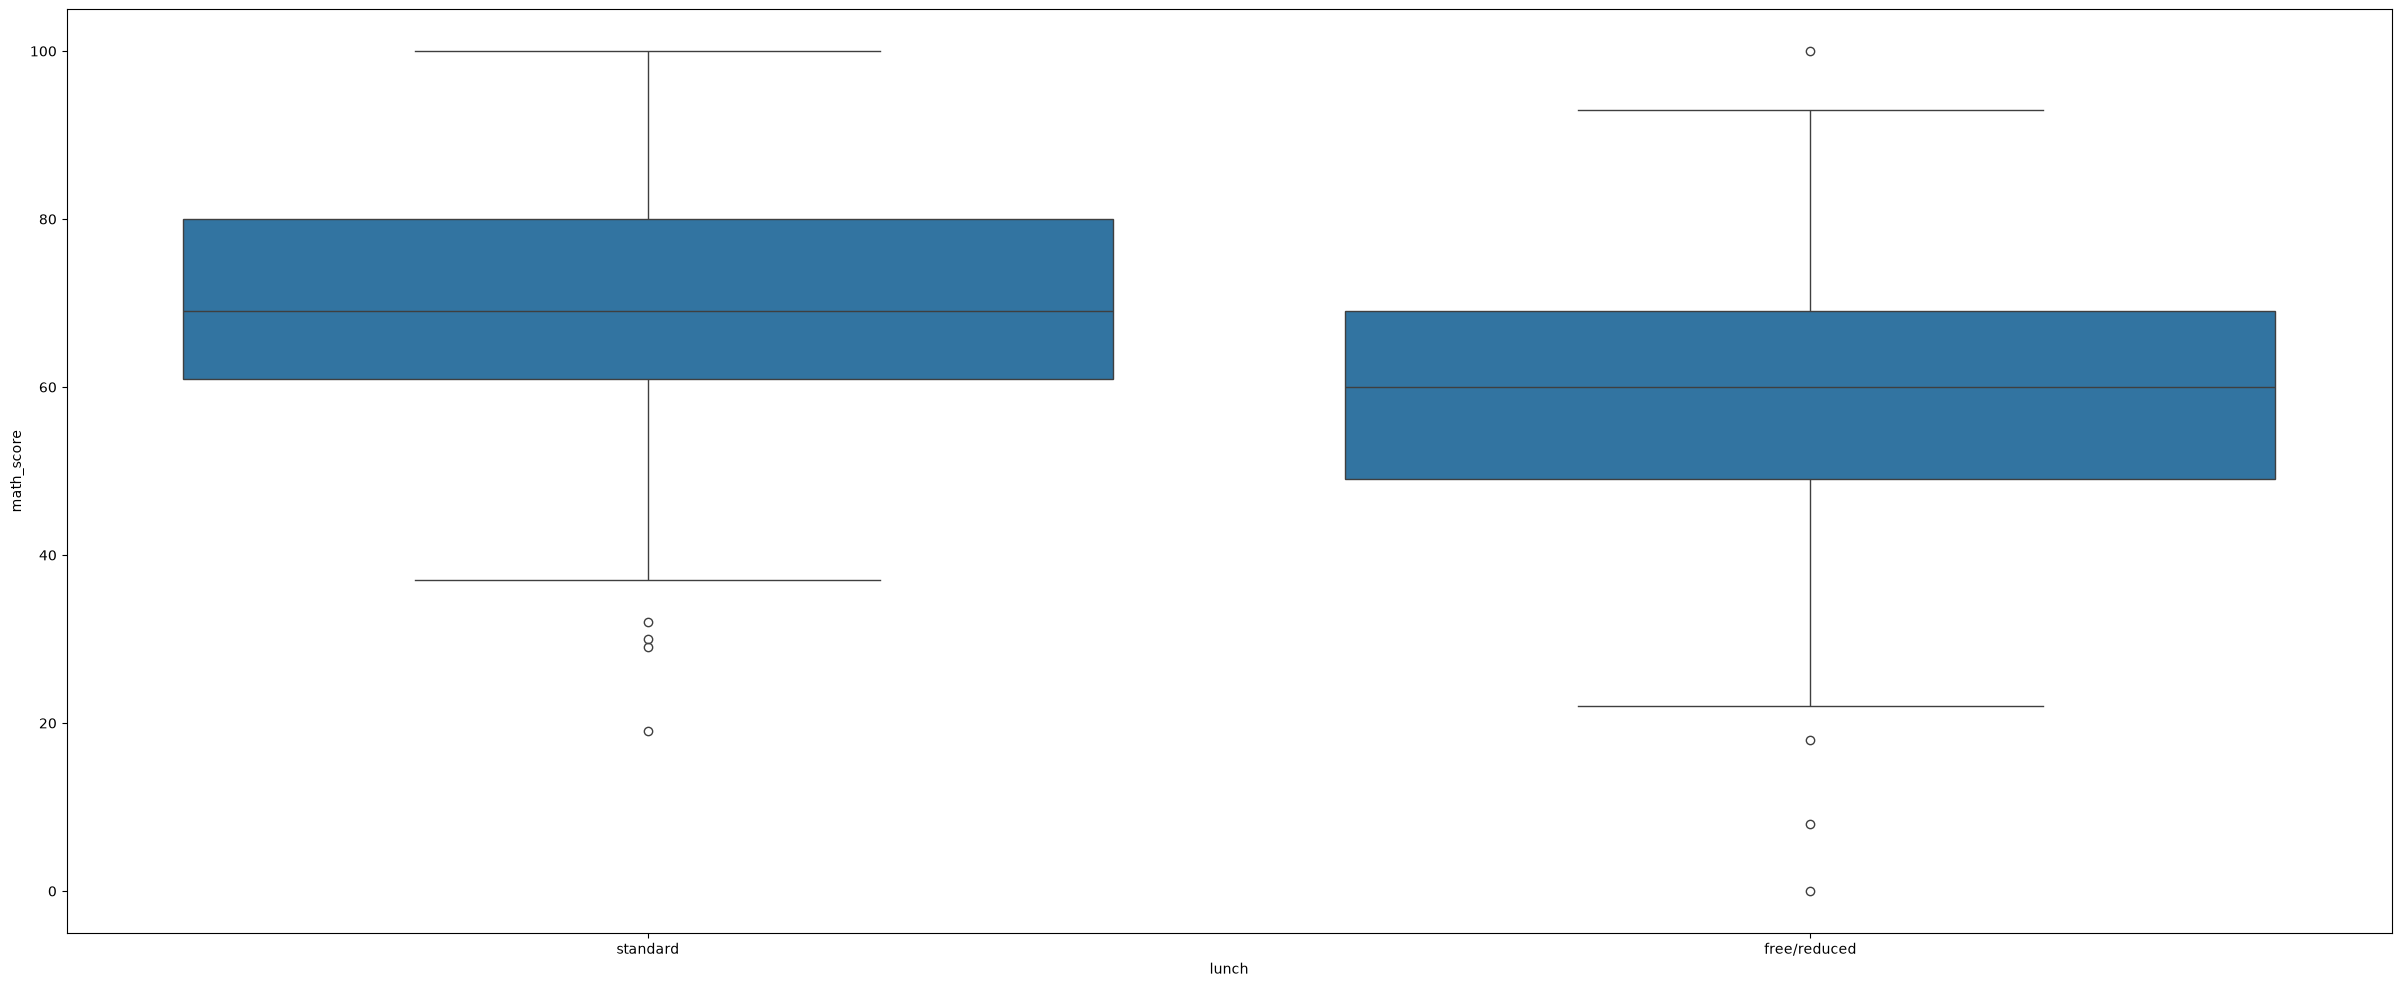

In [68]:
sns.boxplot(
    x='lunch',
    y='math_score',
    data=df
)
plt.show()

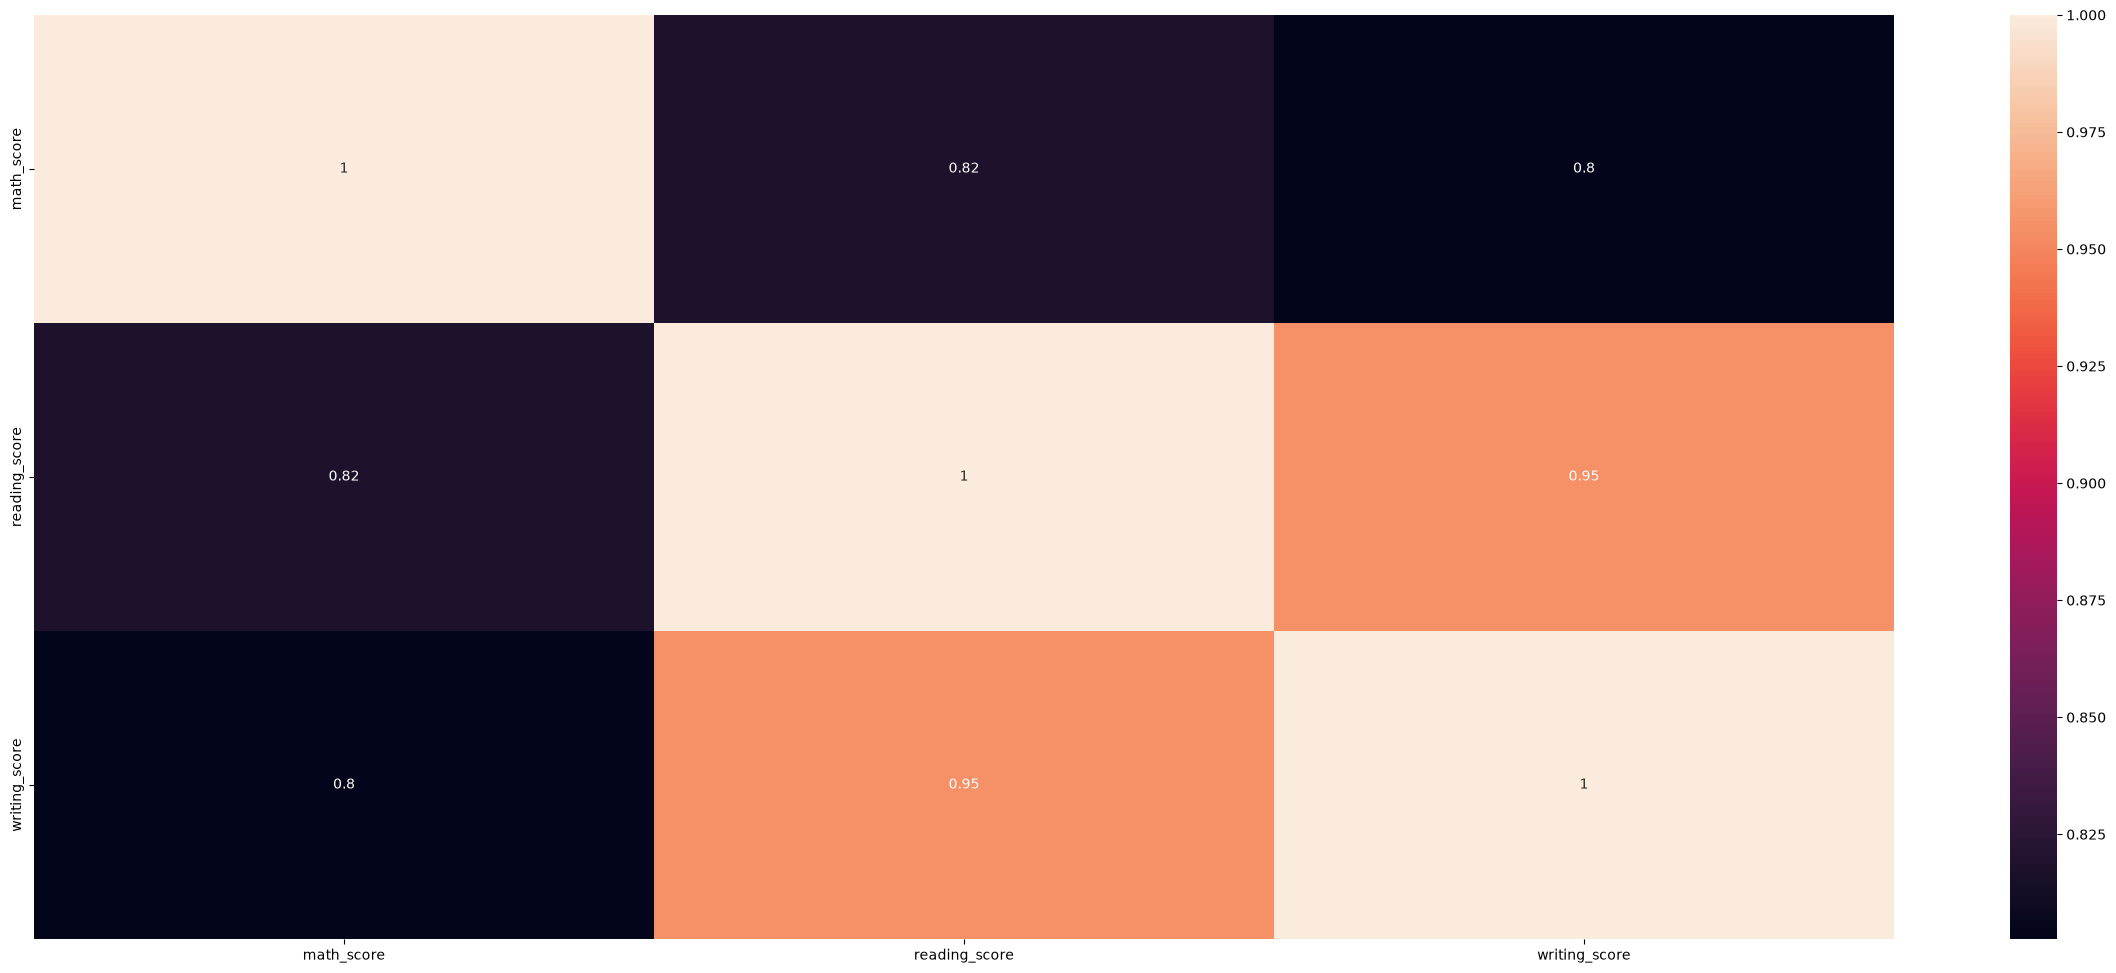

In [69]:
sns.heatmap(
    df[['math_score', 'reading_score', 'writing_score']].corr(),
    annot=True
)

plt.show()

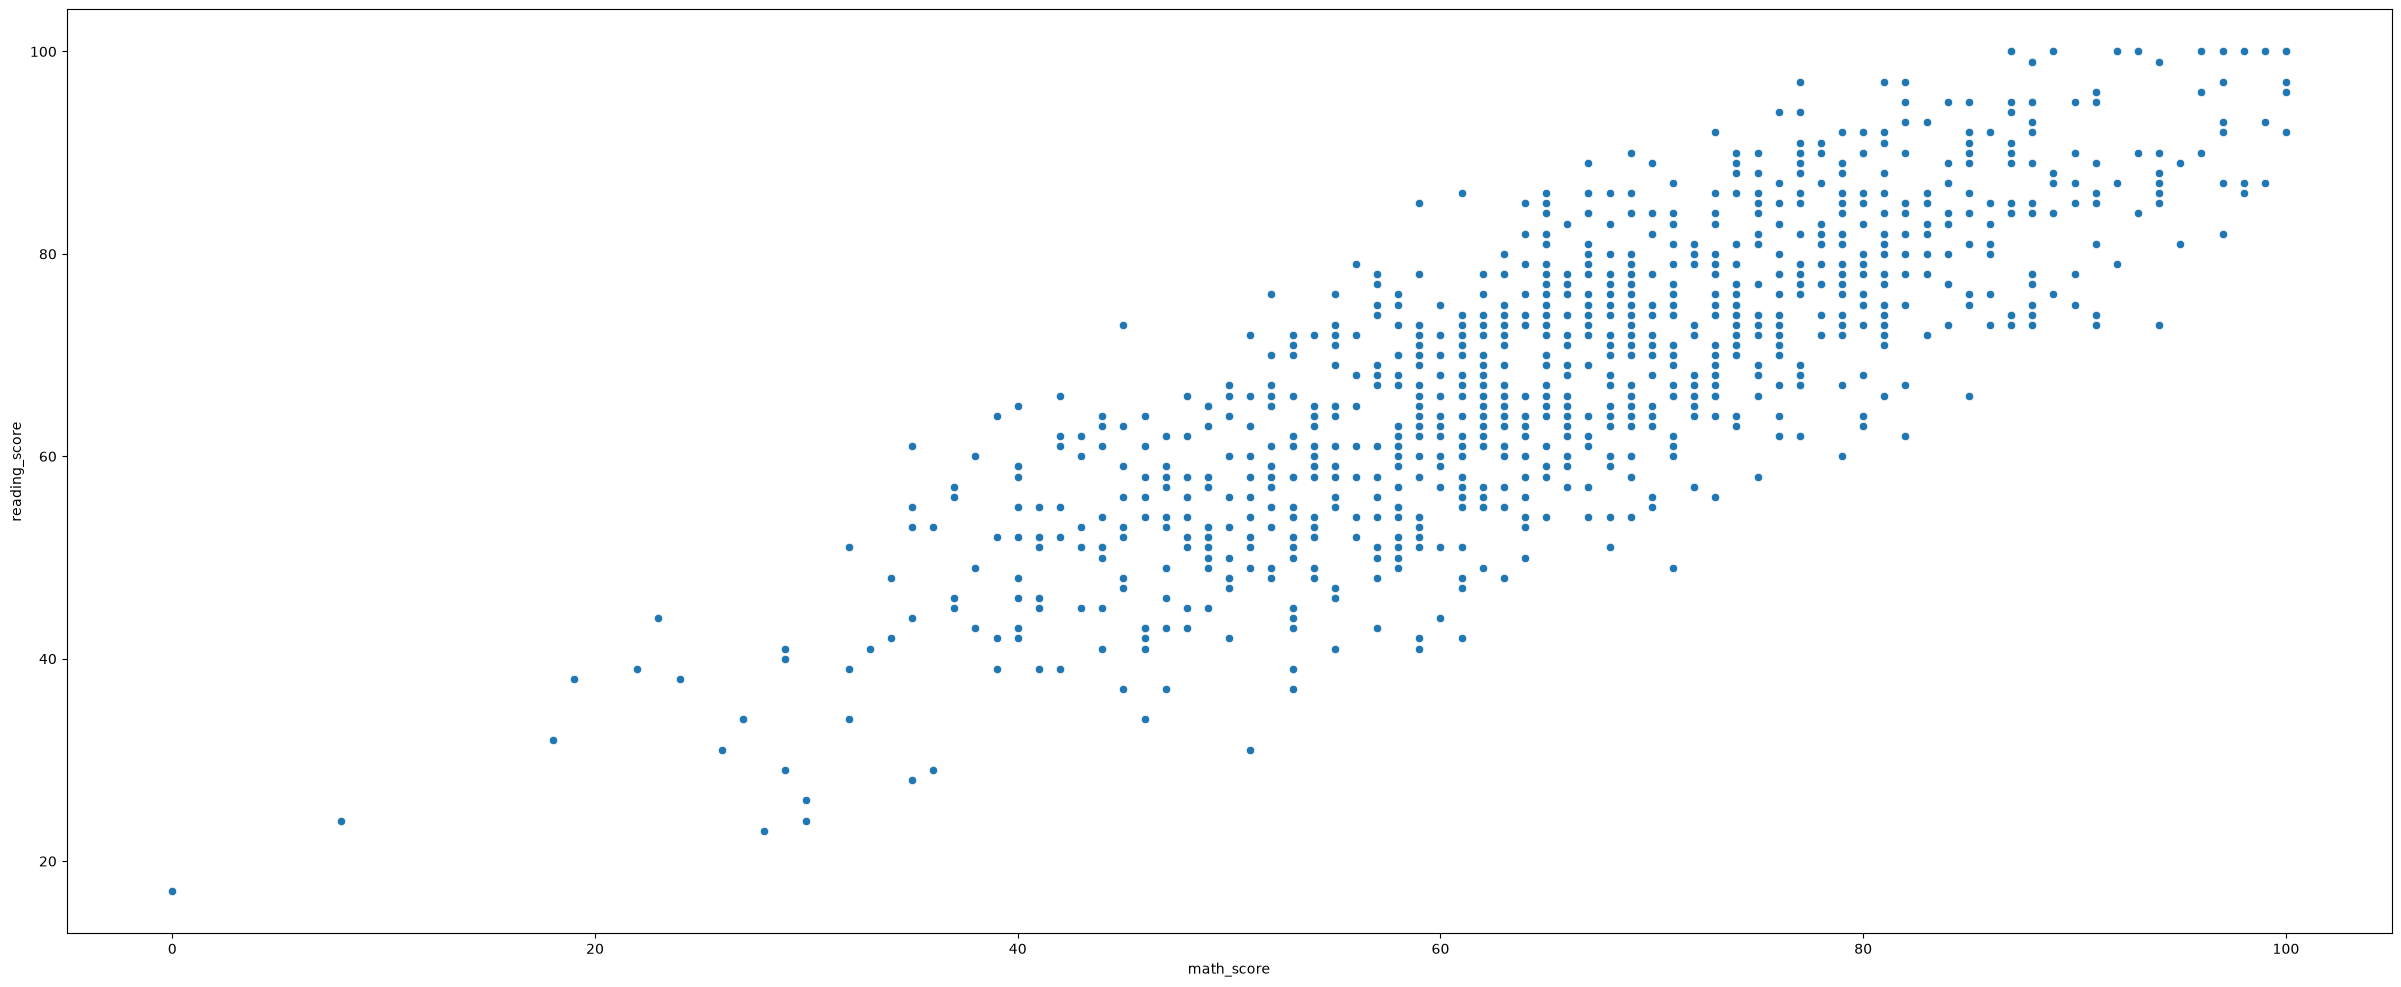

In [70]:
sns.scatterplot(
    x='math_score',
    y='reading_score',
    data=df
)

plt.show()

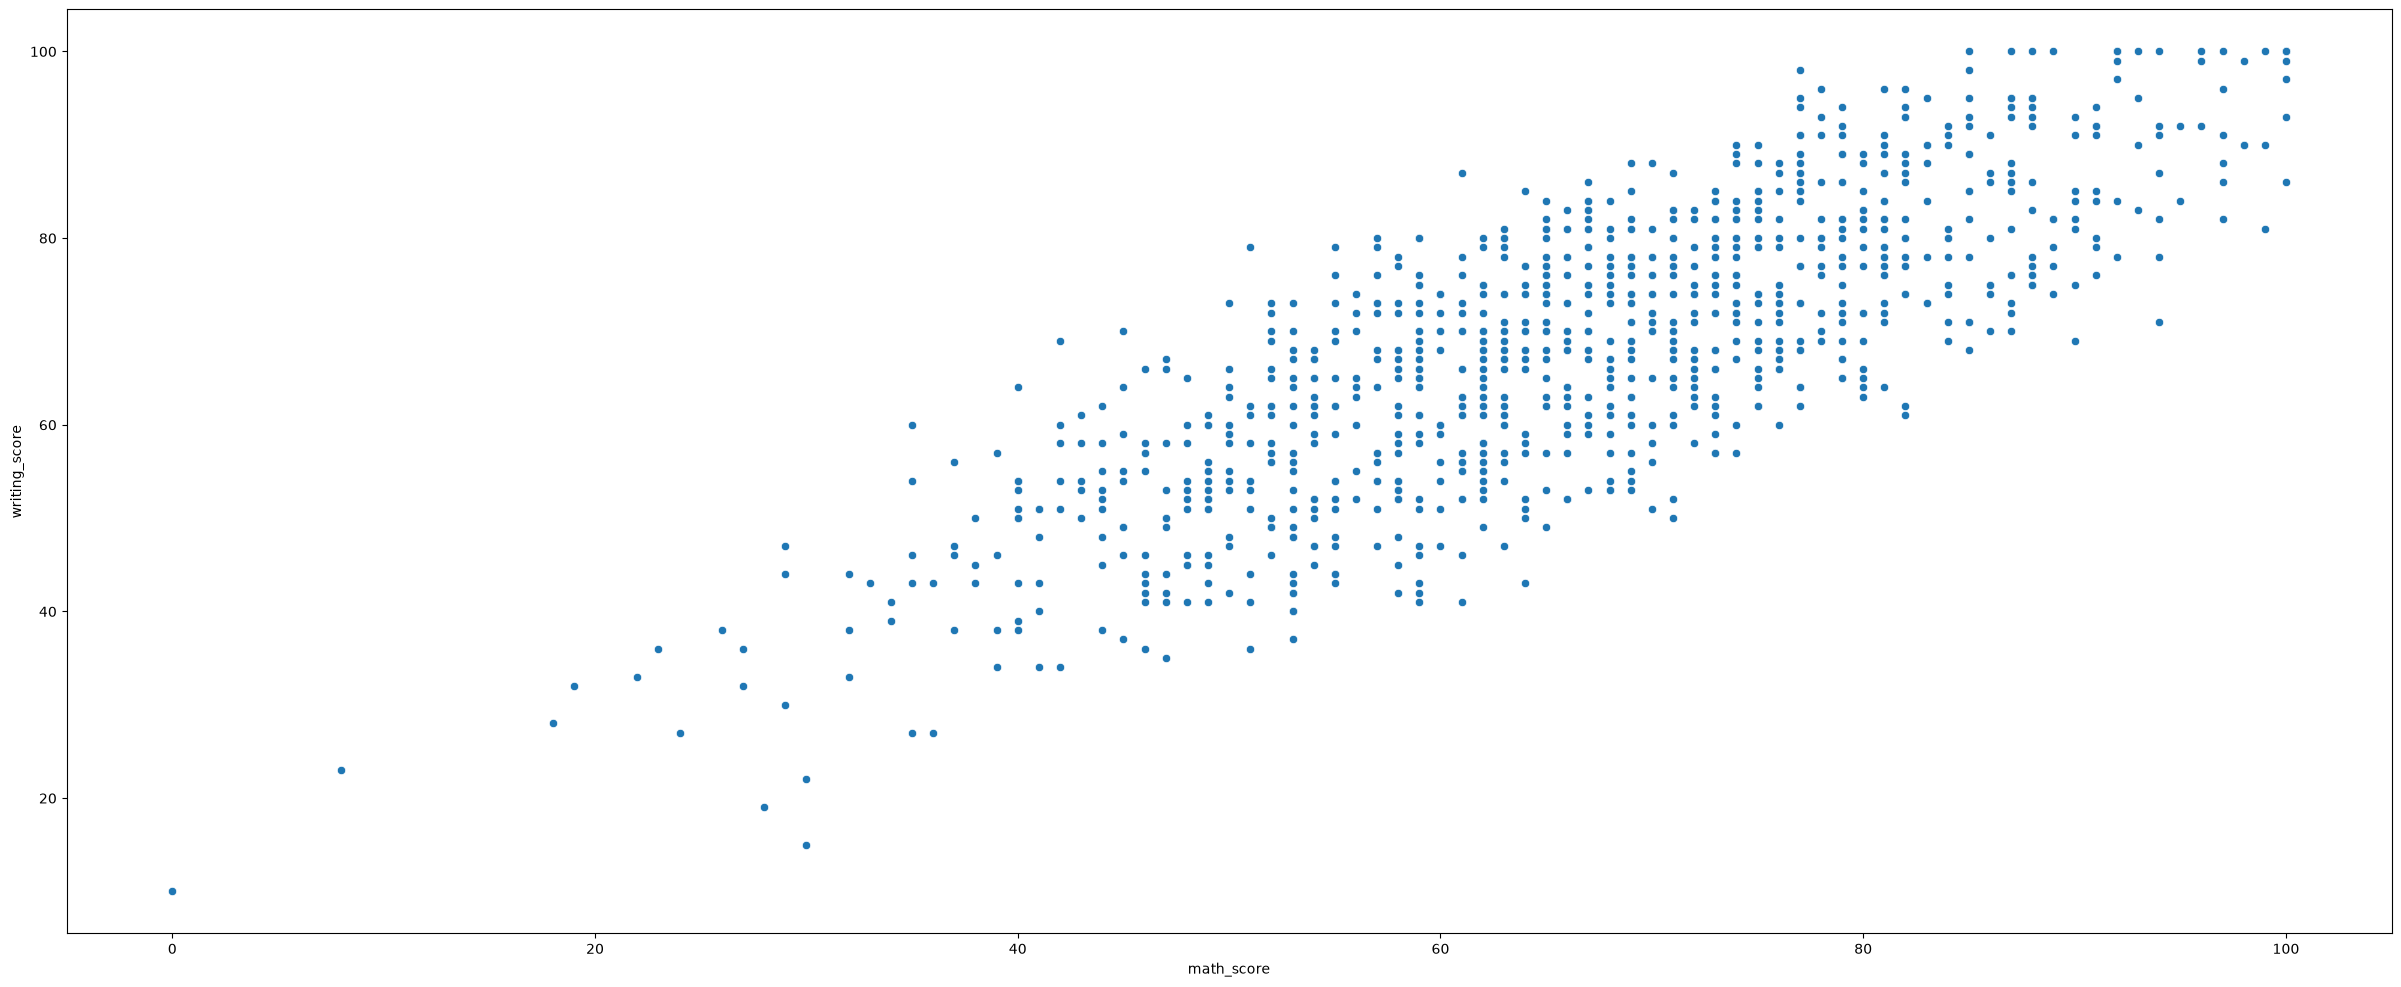

In [71]:

sns.scatterplot(
    x='math_score',
    y='writing_score',
    data=df
)

plt.show()